# Membrane fluctuations with Monte Carlo edge flips

`membrane_fluctuation_resample_cpu.ipynb` measures the bending modulus of a
**solid** sheet: a triangulation that never changes, vertices that never move in
plane. This notebook asks the same question of the **fluid** membrane the
edge-flip work packages produced — flips on, in-plane motion on, the
flat-bottomed tether holding the mesh together — and answers it against the
solid run as a control.

The gate, from `docs/edge_flip_plan.md` work package 6, item 4: *the same*
$\kappa_c$ *from the* $|q|^{-4}$ *fit, and an effective tension that does not
grow* — the flips and the tether must not stiffen the membrane, and the tether
must not put a tension into it.

Two things had to change to make the measurement possible at all, and both are
checked here rather than asserted:

1. **The reader.** The resampler in `membrane_resample.py` inverts the regular
   12-node Loop patch, which is exact only while every interior vertex has
   valence 6. A fluid mesh is mostly not valence 6 (about 56% of interior
   vertices are, after a few thousand steps). `membrane_fluid_surface.py`
   reads the surface by Loop-subdividing the control net on its *actual*
   connectivity with SLIMED's own rules, pushing the result to its limit points
   with the same $(\tfrac12, \tfrac1{2n})$ mask `SurfaceSolver` uses, and
   interpolating onto the Cartesian Monge grid. On the lattice it reproduces
   the exact resampler to round-off; on a flipped mesh it reproduces the limit
   points SLIMED writes to `surfacepoint*.csv`.
2. **The run.** A fluid step costs about 5× a solid one, so the fluid trajectory
   is half the length of the solid control; section 5 checks that it is long
   enough.

### Notes
- Fluidity diagnostics come from `analysis/fluidity.py`, the spectrum
  machinery is still `analysis/membrane_spectrum.py`, and the run definitions
  live in `analysis/fluid_spectrum_runs.py` so a run launched by hand gets the
  same parameter file this notebook expects.
- Set `SLIMED_ALLOW_PARTIAL=1` to analyse a fluid run that is still going: the
  notebook then launches nothing and reads the frames that exist.

In [1]:
import os
import re
import subprocess
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt


def find_repo_root(start=None):
    here = Path(start or Path.cwd()).resolve()
    for d in (here, *here.parents):
        if (d / "CMakeLists.txt").is_file() and (d / "EXEs").is_dir():
            return d
    raise RuntimeError(f"no SLIMED checkout at or above {here}")


REPO = find_repo_root()
sys.path.insert(0, str(REPO))
sys.path.insert(0, str(REPO / "analysis"))
import membrane_spectrum as ms
import membrane_resample as mr
import membrane_fluid_surface as mfs
import fluidity as fl
import fluid_spectrum_runs as fsr

RUNS = Path(os.environ.get("SLIMED_RUNS", Path.home() / "slimed_runs"))
RUNS.mkdir(parents=True, exist_ok=True)
PARTIAL = os.environ.get("SLIMED_ALLOW_PARTIAL") == "1"

KBT = fsr.KBT       # pN.nm, as in input.params
NBLOCK = 8          # blocks behind every error bar
LEVELS = 2          # subdivision levels for the fluid reader; section 6 checks 3

print("repo:", REPO)
print("runs:", RUNS, "(partial runs allowed)" if PARTIAL else "")
print(sorted(p.name for p in RUNS.iterdir() if p.is_dir()))

repo: /Users/yue/Workspace/SLIMED
runs: /Users/yue/slimed_runs (partial runs allowed)
['fast_test', 'fluid_a', 'pure_a', 'tension']


In [2]:
# --- slide styling ----------------------------------------------------------
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 220,
    "figure.facecolor": "white",
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "mathtext.fontset": "custom",
    "mathtext.rm": "Arial",
    "mathtext.it": "Arial:italic",
    "mathtext.bf": "Arial:bold",
    "font.size": 17,
    "axes.labelsize": 20,
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
    "legend.fontsize": 16,
    "legend.frameon": False,
    "legend.handlelength": 1.6,
    "legend.labelspacing": 0.35,
    "lines.linewidth": 2.6,
    "lines.markersize": 9,
    "axes.linewidth": 1.6,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "xtick.direction": "out", "ytick.direction": "out",
    "xtick.major.size": 7, "ytick.major.size": 7,
    "xtick.major.width": 1.6, "ytick.major.width": 1.6,
    "xtick.minor.size": 4, "ytick.minor.size": 4,
    "errorbar.capsize": 3,
})

TEAL  = "#0f766e"
BRICK = "#b1442a"
OCHRE = "#a07a12"
INK   = "#111827"
GREY  = "#8d9794"


def nice_logx(*axes):
    """Plain numbers on a log axis: 0.1, 0.2, 0.3 ... not 2 x 10^-1."""
    from matplotlib.ticker import FixedLocator, FuncFormatter, NullLocator
    fmt = FuncFormatter(lambda v, _: f"{v:g}")
    cand = [m * 10.0 ** d for d in range(-6, 6) for m in (1, 1.5, 2, 3, 5, 7)]
    for ax in axes:
        lo, hi = ax.get_xlim()
        ticks = [c for c in cand if lo <= c <= hi]
        if len(ticks) >= 3:
            ax.xaxis.set_major_locator(FixedLocator(ticks))
            ax.xaxis.set_minor_locator(NullLocator())
            ax.xaxis.set_major_formatter(fmt)


def unique_modes(lat):
    """One representative per conjugate pair, and never the q = 0 mode.

    For a real height field |h_{-q}|^2 equals |h_q|^2 in every frame, so the
    two are the same datapoint, not two.
    """
    keep = np.zeros((lat.ny, lat.nx), bool)
    seen = set()
    for iy in range(lat.ny):
        for ix in range(lat.nx):
            if (iy, ix) == (0, 0):
                continue
            if ((-iy) % lat.ny, (-ix) % lat.nx) in seen:
                continue
            seen.add((iy, ix))
            keep[iy, ix] = True
    return keep


# --- how far up in q the continuum law may be fitted ------------------------
# |q|*dFaceX = pi is the Nyquist wavevector of the mesh spacing, so pi/2 is half
# of it: four mesh cells per wavelength.  That the discretisation is still
# faithful there is measured, not assumed -- tests/test_continuum_limit.cpp
# puts an exact plane wave on the control net, reads the bending energy the
# production code returns, and refers the stiffness to the limit surface.
QDX_MAX = np.pi / 2

# |q|*dFaceX -> K_S(|q|) / (A kc |q|^4), from tests/test_continuum_limit.cpp.
# A function of |q|*dFaceX alone: the same numbers come back on a mesh twice as
# fine.  1 where the mesh is faithful; 0.995 at pi/2.
FORM_FACTOR = np.array([
    [0.000, 1.0000], [0.403, 1.0000], [0.603, 0.9999], [0.898, 0.9992],
    [1.209, 0.9979], [1.346, 0.9953], [1.612, 0.9919], [1.810, 0.9845],
    [2.015, 0.9754], [2.244, 0.9497], [2.418, 0.9355], [2.821, 0.8509],
    [3.225, 0.7002],
])


def form_factor(q_mag, d_face_x):
    """How much softer than the continuum this mesh is at |q|."""
    return np.interp(q_mag * d_face_x, FORM_FACTOR[:, 0], FORM_FACTOR[:, 1])


print(f"continuum window: |q|*dFaceX <= pi/2 = {QDX_MAX:.4f}"
      f"  (lambda >= 4 cells; lattice error {1-form_factor(QDX_MAX, 1.0):.1%})")

continuum window: |q|*dFaceX <= pi/2 = 1.5708  (lambda >= 4 cells; lattice error 0.8%)


---
## 0. The runs

Two trajectories of the same 100 nm periodic box (nFace 20 × 24, a 14 × 18
tile), both from the CPU build with OpenMP on. `pure_a` is the solid control
exactly as `membrane_fluctuation_resample_cpu.ipynb` made it, and is kept if
it exists. `fluid_a` is the same sheet with the fluid flags added and nothing
else changed — except the time step, for the reason in section 7.

| run | what it is | steps | Δt | frame every |
| --- | --- | ---: | ---: | ---: |
| `pure_a` | solid, $\mu_S = 0$: the control | 800 000 | 0.002 µs | 100 |
| `fluid_a` | flips at $\nu = 0.5$/edge/µs, in-plane motion, flat tether $[0.95, 1.75]\,l$ | 400 000 planned | 0.001 µs | 100 |

Expect a few hours for the fluid run on eight threads. If a run diverged —
which every long fluid run did before the ghost-band fix described in section
7 — the cell below says so and the notebook analyses the frames written before
it.

In [3]:
BUILD = REPO / "build-omp"
EXE = BUILD / "bin" / "membrane_dynamics"
SCALE = float(os.environ.get("SLIMED_STEPS_SCALE", 1.0))


def cmake(*args):
    p = subprocess.run(["cmake", *args], capture_output=True, text=True)
    if p.returncode:
        raise RuntimeError("cmake " + " ".join(args) + " failed:\n" + (p.stdout + p.stderr)[-2000:])


def openmp_binary():
    cache = BUILD / "CMakeCache.txt"
    on = cache.is_file() and "SLIMED_ENABLE_OPENMP:BOOL=ON" in cache.read_text()
    if on and EXE.is_file():
        return EXE
    if not on:
        cmake("-S", str(REPO), "-B", str(BUILD), "-DSLIMED_ENABLE_OPENMP=ON", "-DCMAKE_BUILD_TYPE=Release")
    cmake("--build", str(BUILD), "--target", "membrane_dynamics", "-j", str(os.cpu_count() or 4))
    return EXE


CONTROL, FLUID_RUN = "pure_a", "fluid_a"
SPECS = {k: fsr.SPECS[k] for k in (CONTROL, FLUID_RUN)}
found = fsr.generate(RUNS, EXE if PARTIAL else openmp_binary(), SPECS, scale=SCALE, launch=not PARTIAL)

CTRL, FLUID = RUNS / CONTROL, RUNS / FLUID_RUN
DIVERGED = {}
for name, d in ((CONTROL, CTRL), (FLUID_RUN, FLUID)):
    log = (d / "run.log").read_text()[-6000:] if (d / "run.log").is_file() else ""
    m = re.search(r"energy is nan at iteration (\d+); the run has diverged", log)
    DIVERGED[name] = int(m.group(1)) if m else None
    print(f"{name:8s} {found[name]:9s} {fsr.last_iteration(d / 'run.log'):>8,} steps in the log"
          + (f"   ** DIVERGED at step {DIVERGED[name]:,}; only the frames before it are analysed **" if m else ""))
if DIVERGED[FLUID_RUN]:
    print("\nThe fluid run did not reach its planned length. Section 7 says what happened; everything")
    print("below is measured on the frames written before the divergence, over which the bending")
    print("energy was stationary and the control net was not.")

pure_a       finished already, keeping it
fluid_a      finished already, keeping it
pure_a   finished   800,000 steps in the log
fluid_a  finished    94,078 steps in the log   ** DIVERGED at step 94,078; only the frames before it are analysed **

The fluid run did not reach its planned length. Section 7 says what happened; everything
below is measured on the frames written before the divergence, over which the bending
energy was stationary and the control net was not.


---
## 1. Is it fluid?

Before measuring a spectrum of a fluid membrane, establish that it is one.
Three diagnostics from `fluidity.py`, each of which a solid sheet fails:

* **Neighbour survival** — the fraction of the initial edges still present.
  Exactly 1 forever with flips off. Its decay is the microscopic fluidity time.
* **The valence histogram** — a dynamically triangulated surface at equilibrium
  sits near 60% valence 6 with the rest spread over 5 and 7; a lattice is 100% 6.
* **The accepted energy differences** — a Metropolis chain sampling the
  Hamiltonian the dynamics integrates accepts moves that straddle zero. A mean
  far from zero was, when it happened, the sign that the flip trial and the
  Brownian step were differencing different terms.

In [4]:
fluid = fl.load_run(str(FLUID), output_interval=int(SPECS[FLUID_RUN]["meshpointOutputInterval"]))
if DIVERGED[FLUID_RUN]:
    # The energy was finite until about a hundred steps before the guard fired,
    # and the frames written after that are astronomical. Cut well clear of it.
    fluid = fl.truncate(fluid, DIVERGED[FLUID_RUN] - 500)
    print(f"analysing {fluid.coords.shape[0]} frames, to iteration {fluid.frame_iterations[-1]}\n")
print(fl.report(fluid))

summary = fl.acceptance_summary(fluid, n_windows=8)
accepted_dE = fluid.flip_delta_energy[fluid.flip_accepted]
print(f"\naccepted dE over the whole run: mean {accepted_dE.mean():+.3f}, median {np.median(accepted_dE):+.3f} pN.nm"
      f"  ({accepted_dE.mean() / KBT:+.3f} kT)")

analysing 936 frames, to iteration 93500



run: /Users/yue/slimed_runs/fluid_a
  frames 936, vertices 525 (252 free), face frames 904
  flips: 3450/15380 = 0.224 acceptance
    steps      0- 23393:  973/4035 (0.241), mean dE +0.084, median +0.146
    steps  23393- 46786:  859/3896 (0.220), mean dE -0.196, median -0.031
    steps  46786- 70179:  805/3751 (0.215), mean dE -0.264, median -0.074
    steps  70179- 93573:  813/3698 (0.220), mean dE -0.238, median -0.043
  valences at step 93500 (221 interior free vertices, mean 6.014): 4:0.109, 5:0.131, 6:0.489, 7:0.181, 8:0.090
  neighbour survival: 0.815 at step 93500, 1/e time nan
  in-plane MSD: 0.5579 nm^2 at lag 100, 16.4559 at lag 46800, growth exponent 0.578
  edge lengths: mean 5.873 +- 1.582 nm, range [2.304, 15.797], 1-99% [4.139, 10.918]

accepted dE over the whole run: mean -0.143, median +0.006 pN.nm  (-0.034 kT)


findfont: Failed to find font weight normal, now using 0.


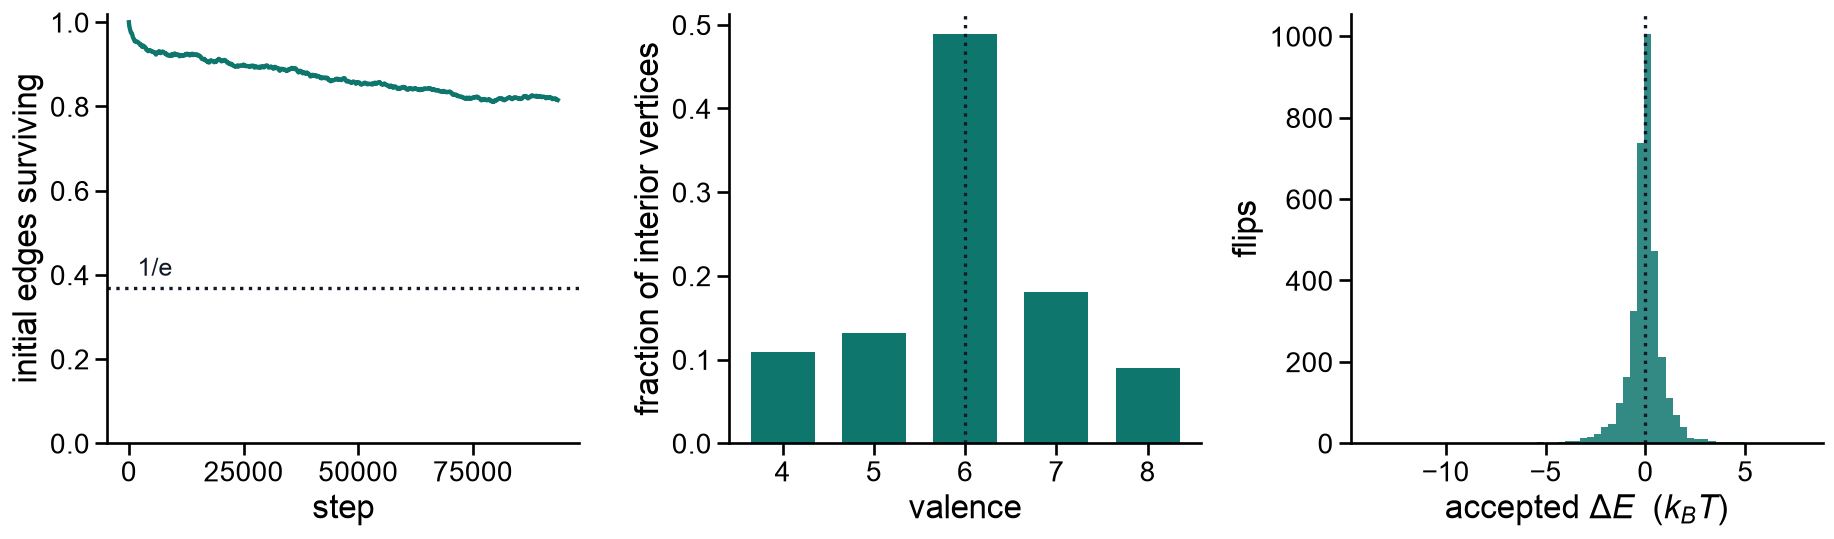

neighbour survival: 0.815 at step 93500; 1/e not reached
valences at the last frame: 4: 0.109, 5: 0.131, 6: 0.489, 7: 0.181, 8: 0.090  (mean 6.014)
edge lengths at the last frame: 5.87 +- 1.58 nm, 1-99% [4.14, 10.92] against tether walls at [4.75, 8.75]


In [5]:
times, survival = fl.neighbour_survival(fluid)
last_faces = fluid.face_frames[max(fluid.face_frames)]
hist = fl.valence_histogram(last_faces, fluid.free_vertices)
lengths = fl.edge_length_stats(fluid)
l0 = float(SPECS[FLUID_RUN].get("lFace", fsr.COMMON["lFace"]))
lo_wall, hi_wall = fsr.FLUID["edgeTetherMinRatio"] * l0, fsr.FLUID["edgeTetherMaxRatio"] * l0

fig, axes = plt.subplots(1, 3, figsize=(15.6, 4.8))
ax = axes[0]
ax.plot(times, survival, "-", color=TEAL, lw=2.6)
ax.axhline(1 / np.e, color=INK, ls=":", lw=2.0)
ax.set_xlabel("step"); ax.set_ylabel("initial edges surviving")
ax.set_ylim(0, 1.02)
ax.text(times[-1] * 0.02, 1 / np.e + 0.03, "1/e", color=INK, fontsize=15)

ax = axes[1]
ks = sorted(hist["fractions"])
ax.bar(ks, [hist["fractions"][k] for k in ks], color=TEAL, width=0.7)
ax.axvline(6, color=INK, ls=":", lw=2.0)
ax.set_xlabel("valence"); ax.set_ylabel("fraction of interior vertices")
ax.set_xticks(ks)

ax = axes[2]
ax.hist(accepted_dE / KBT, bins=60, color=TEAL, alpha=0.85)
ax.axvline(0, color=INK, ls=":", lw=2.0)
ax.set_xlabel(r"accepted $\Delta E$  ($k_BT$)"); ax.set_ylabel("flips")
plt.tight_layout()
plt.show()

t_e = fl.survival_time(times, survival)
print(f"neighbour survival: {survival[-1]:.3f} at step {times[-1]}; "
      + (f"1/e reached at step {t_e:.0f}" if np.isfinite(t_e) else "1/e not reached"))
print(f"valences at the last frame: " + ", ".join(f"{k}: {v:.3f}" for k, v in hist['fractions'].items())
      + f"  (mean {hist['mean']:.3f})")
print(f"edge lengths at the last frame: {lengths['mean']:.2f} +- {lengths['std']:.2f} nm, "
      f"1-99% [{lengths['percentiles'][1]:.2f}, {lengths['percentiles'][99]:.2f}] "
      f"against tether walls at [{lo_wall:.2f}, {hi_wall:.2f}]")

---
## 2. Reading a surface that is no longer a lattice

`membrane_resample.LimitSurface` finds, for a requested $(x, y)$, the regular
12-node patch and the barycentric $(v, w)$ whose limit point projects there. On
a flipped mesh most faces are not regular patches, and it has nothing to
evaluate.

`membrane_fluid_surface.SubdividedSurface` does not need the patch. It applies
Loop subdivision to the whole control net on its actual connectivity — the
same rules as `Mesh::refine_loop_once()` and `Subdivision_matrices.hpp`,
Warren's $\beta = 3/8n$ — $k$ times, pushes every vertex of the result to its
limit position, and interpolates linearly between those limit points. Every
step is a linear map that depends only on the connectivity, so one sparse
matrix per distinct connectivity does the whole thing.

Three checks. On the lattice, every Cartesian grid point coincides with a
fine-net vertex from the first level on, so the route must be **exact** there
— not close. Off the vertices it is linear interpolation, whose error must
fall by about 4× per level. And on the fluid run's flipped frames, the limit
points it computes for the original vertices must equal the ones the C++ wrote
to `surfacepoint*.csv`, which is an exact test against SLIMED on exactly the
connectivity the resampler cannot handle.

In [6]:
lat = ms.lattice_from_params(CTRL / "input.params")
lat_f = ms.lattice_from_params(FLUID / "input.params")
assert (lat.nx, lat.ny) == (lat_f.nx, lat_f.ny), "the two runs are not the same tile"

par = {}
for line in open(CTRL / "input.params"):
    if "=" in line and not line.strip().startswith("#"):
        k, v = line.split("=", 1)
        par[k.strip()] = v.split("#")[0].strip()
KC_IN = float(par["kcMembraneBending"])
DIFF = float(par["diffConst"])
DT_FRAME_C = float(par["timeStep"]) * int(par.get("meshpointOutputInterval", 1))
DT_FRAME_F = float(SPECS[FLUID_RUN]["timeStep"]) * int(SPECS[FLUID_RUN]["meshpointOutputInterval"])
A_CELL = lat.area / (lat.nx * lat.ny)

ctrl = fl.load_run(str(CTRL), output_interval=int(par.get("meshpointOutputInterval", 1)))
z = ms.read_tile_heights(CTRL / "meshpointinput.csv", lat)        # control heights, every frame
net = mr.reference_net(CTRL / "meshpointinput.csv", lat)
surf = mr.LimitSurface(lat, net)
X, Y = surf.monge_grid("cartesian")
R_exact = surf.solve(X, Y)
print(lat.describe())
print(f"control: {len(z)} frames, exact solve residual {R_exact.residual:.1e} nm")

# --- on the lattice the route is exact -------------------------------------
probe = np.arange(len(z) // 5, len(z), max(1, len(z) // 20))[:20]
exact_probe = R_exact.apply(z[probe])
Xs, Ys = X + 0.137 * lat.d_face_x, Y + 0.291 * lat.d_face_y      # off every vertex, at every level
exact_shift = surf.solve(Xs, Ys).apply(z[probe])
print(f"\n{len(probe)} control frames, r.m.s. h = {exact_probe.std():.3f} nm")
print(f"{'levels':>7} {'fine vertices':>14} {'on the grid':>13} {'off the grid, rms':>18} {'ms/frame':>9}")
for levels in (1, 2, 3):
    s = mfs.SubdividedSurface(ctrl.face_frames[0], ctrl.coords.shape[1], levels)
    t0 = time.perf_counter()
    h_on = np.array([s.interpolate(ctrl.coords[f], X, Y) for f in probe])
    per_frame = (time.perf_counter() - t0) / len(probe)
    h_off = np.array([s.interpolate(ctrl.coords[f], Xs, Ys) for f in probe])
    print(f"{levels:>7} {s.n_fine:>14,} {np.abs(h_on - exact_probe).max():>13.1e} "
          f"{np.sqrt(np.mean((h_off - exact_shift) ** 2)):>18.2e} {per_frame * 1e3:>9.1f}")
print("on the grid: round-off (the CSV carries 8 significant digits); off it: linear interpolation, ~4x per level")

mesh 21 x 25 vertices (nFace 20 x 24), cell 5 x 4.33013 nm
periodic tile 14 x 18 = 252 vertices, Lx = 70 nm, Ly = 77.9423 nm, A = 5455.96 nm^2
control: 8001 frames, exact solve residual 1.4e-14 nm

17 control frames, r.m.s. h = 1.137 nm
 levels  fine vertices   on the grid  off the grid, rms  ms/frame


      1          2,009       4.5e-08           2.05e-02      33.8


      2          7,857       3.3e-08           2.49e-03     138.4


      3         31,073       2.4e-08           1.07e-03     694.0
on the grid: round-off (the CSV carries 8 significant digits); off it: linear interpolation, ~4x per level


In [7]:
def read_frames(path, n_vertices):
    rows = []
    with open(path) as fh:
        for line in fh:
            line = line.strip().rstrip(",")
            if line:
                rows.append(np.fromstring(line, sep=","))
    widths = {}
    for r in rows:
        widths[len(r)] = widths.get(len(r), 0) + 1
    w = max(widths, key=widths.get)
    return np.array([r for r in rows if len(r) == w]).reshape(-1, n_vertices, 3)


S_cpp = read_frames(FLUID / "surfacepointinput.csv", fluid.coords.shape[1])
n_cmp = min(len(S_cpp), fluid.coords.shape[0])

# S = M C holds where nothing in the one-ring is overwritten after the solve:
# the periodic post-process rewrites ghost and duplicate vertices, so compare
# vertices at least six rings inside the sheet, whose neighbours are all free.
ring = np.array([min(i, j, lat.n_face_x - i, lat.n_face_y - j)
                 for j in range(lat.n_vert_y) for i in range(lat.n_vert_x)])
deep = ring >= 6

worst, worst_frame, with_extraordinary, compared = 0.0, None, 0, 0
for f in range(1, n_cmp, max(1, n_cmp // 40)):
    faces = mfs.connectivity_for_frame(fluid.face_frames, int(fluid.frame_iterations[f]))
    conn = mfs.Connectivity(faces, fluid.coords.shape[1])
    with_extraordinary += int((conn.valence[deep] != 6).any())
    mine = mfs.SubdividedSurface(faces, fluid.coords.shape[1], levels=0).original_vertex_limits(fluid.coords[f])
    err = np.abs(mine[deep] - S_cpp[f][deep]).max()
    compared += 1
    if err > worst:
        worst, worst_frame = err, f
print(f"fluid run: {compared} frames compared on {deep.sum()} deep-interior vertices, "
      f"{with_extraordinary} of the frames with extraordinary vertices among them")
print(f"max |limit point (Python) - surfacepoint (C++)| = {worst:.2e} nm  at frame {worst_frame}")
print("the CSV carries 8 significant digits on coordinates of order 50, so 1e-6 nm is its resolution")
assert worst < 1e-5, "the subdivision route does not reproduce SLIMED's limit points on the flipped mesh"

fluid run: 41 frames compared on 117 deep-interior vertices, 41 of the frames with extraordinary vertices among them
max |limit point (Python) - surfacepoint (C++)| = 8.17e-07 nm  at frame 1
the CSV carries 8 significant digits on coordinates of order 50, so 1e-6 nm is its resolution


---
## 3. The spectra

The control goes through the exact resampler, and — so that the comparison is
between membranes and not between readers — also through the subdivision
route at the same level the fluid run gets. The fluid run goes through the
subdivision route. Everything is then the same pipeline as the solid notebook:
a bare `fft2` on the Cartesian grid, block-averaged power with a standard
error from `NBLOCK` time blocks, and a fit of $k_BT/(A(\kappa_c|q|^4 +
\sigma|q|^2))$ over $|q|\,d_x \le \pi/2$.

In [8]:
def block_power(H, lat_, nblock=NBLOCK):
    n = len(H)
    edges = np.linspace(0, n, nblock + 1).astype(int)
    per = np.array([np.mean(np.abs(H[a:b]) ** 2, axis=0) for a, b in zip(edges[:-1], edges[1:])])
    per /= (lat_.nx * lat_.ny) ** 2
    return per.mean(axis=0), per.std(axis=0, ddof=1) / np.sqrt(nblock)


keep = unique_modes(lat)
_, _, q2d = mr.cartesian_q_grid(lat)


def blockwise(h, lat_=lat, nblock=NBLOCK):
    # (kc, sigma) fitted per time block: mean and standard error over the blocks
    n = len(h)
    edges = np.linspace(0, n, nblock + 1).astype(int)
    out = []
    for a, b in zip(edges[:-1], edges[1:]):
        H = np.fft.fft2(h[a:b], axes=(-2, -1))
        S2d = np.mean(np.abs(H) ** 2, axis=0) / (lat_.nx * lat_.ny) ** 2
        qv, Sv = q2d[keep], S2d[keep]
        win = qv * lat_.d_face_x <= QDX_MAX
        out.append(ms.fit_kc_sigma(qv[win], Sv[win], lat_.area, KBT))
    out = np.array(out)
    return out.mean(axis=0), out.std(axis=0, ddof=1) / np.sqrt(nblock)


def fit_spectrum(h, lat_=lat):
    S2d, E2d = block_power(np.fft.fft2(h, axes=(-2, -1)), lat_)
    qv, Sv, Ev = q2d[keep], S2d[keep], E2d[keep]
    o = np.argsort(qv)
    qv, Sv, Ev = qv[o], Sv[o], Ev[o]
    win = qv * lat_.d_face_x <= QDX_MAX
    slope = np.polyfit(np.log10(qv[win]), np.log10(Sv[win]), 1, w=Sv[win] / np.maximum(Ev[win], 1e-30))[0]
    kc, sigma = ms.fit_kc_sigma(qv[win], Sv[win], lat_.area, KBT)
    kc_eff = KBT / (lat_.area * qv ** 4 * Sv)
    return dict(q=qv, S=Sv, E=Ev, win=win, slope=slope, kc=kc, sigma=sigma,
                kc_eff=kc_eff, kc_err=kc_eff * Ev / Sv, n=len(h))


# control: exact, every frame after burn-in; and the subdivision route on half of them
BURN_C = len(z) // 5
h_ctrl_exact = R_exact.apply(z[BURN_C:])
sel_c = np.arange(BURN_C, ctrl.coords.shape[0], 2)
t0 = time.perf_counter()
h_ctrl_sub = mfs.monge_heights(ctrl.coords[sel_c], ctrl.frame_iterations[sel_c], ctrl.face_frames, X, Y, LEVELS)
print(f"control through the subdivision route: {len(sel_c)} frames in {time.perf_counter() - t0:.0f} s")

# fluid: the subdivision route, every frame after burn-in, on the same grid
BURN_F = fluid.coords.shape[0] // 5
t0 = time.perf_counter()
h_fluid = mfs.monge_heights(fluid.coords[BURN_F:], fluid.frame_iterations[BURN_F:], fluid.face_frames, X, Y, LEVELS)
print(f"fluid through the subdivision route:   {len(h_fluid)} frames in {time.perf_counter() - t0:.0f} s, "
      f"{len(set(k for k in fluid.face_frames if k >= fluid.frame_iterations[BURN_F]))} distinct connectivities")
assert np.isfinite(h_fluid).all(), "a grid point fell outside the fluid mesh"

results = {
    "control, exact resampler": fit_spectrum(h_ctrl_exact),
    f"control, subdivision L{LEVELS}": fit_spectrum(h_ctrl_sub),
    f"fluid, subdivision L{LEVELS}": fit_spectrum(h_fluid),
}
print(f"\n{'':28s} {'frames':>6} {'modes':>5} {'slope':>7} {'kc (pN.nm)':>11} {'(kT)':>6} {'sigma (pN/nm)':>14} {'<kc_eff> in window':>19}")
for tag, r in results.items():
    w = r["win"]
    print(f"{tag:28s} {r['n']:>6} {w.sum():>5} {r['slope']:>+7.3f} {r['kc']:>11.2f} {r['kc'] / KBT:>6.1f} "
          f"{r['sigma']:>+14.3f} {r['kc_eff'][w].mean():>9.2f} +- {r['kc_eff'][w].std(ddof=1) / np.sqrt(w.sum()):.2f}")
print(f"\ninput kc = {KC_IN} pN.nm ({KC_IN / KBT:.0f} kT)")
rc, rf = results[f"control, subdivision L{LEVELS}"], results[f"fluid, subdivision L{LEVELS}"]
print(f"fluid / control at equal treatment: kc ratio {rf['kc'] / rc['kc']:.3f}, "
      f"sigma difference {rf['sigma'] - rc['sigma']:+.3f} pN/nm")

control through the subdivision route: 3201 frames in 224 s


fluid through the subdivision route:   749 frames in 48 s, 725 distinct connectivities

                             frames modes   slope  kc (pN.nm)   (kT)  sigma (pN/nm)  <kc_eff> in window
control, exact resampler       6401    22  -3.974       91.51   21.9         +0.013     91.97 +- 1.88
control, subdivision L2        3201    22  -3.968       91.47   21.9         +0.014     91.96 +- 1.89
fluid, subdivision L2           749    22  -4.326       91.97   22.1         +0.297    102.22 +- 8.40

input kc = 83.4 pN.nm (20 kT)
fluid / control at equal treatment: kc ratio 1.005, sigma difference +0.283 pN/nm


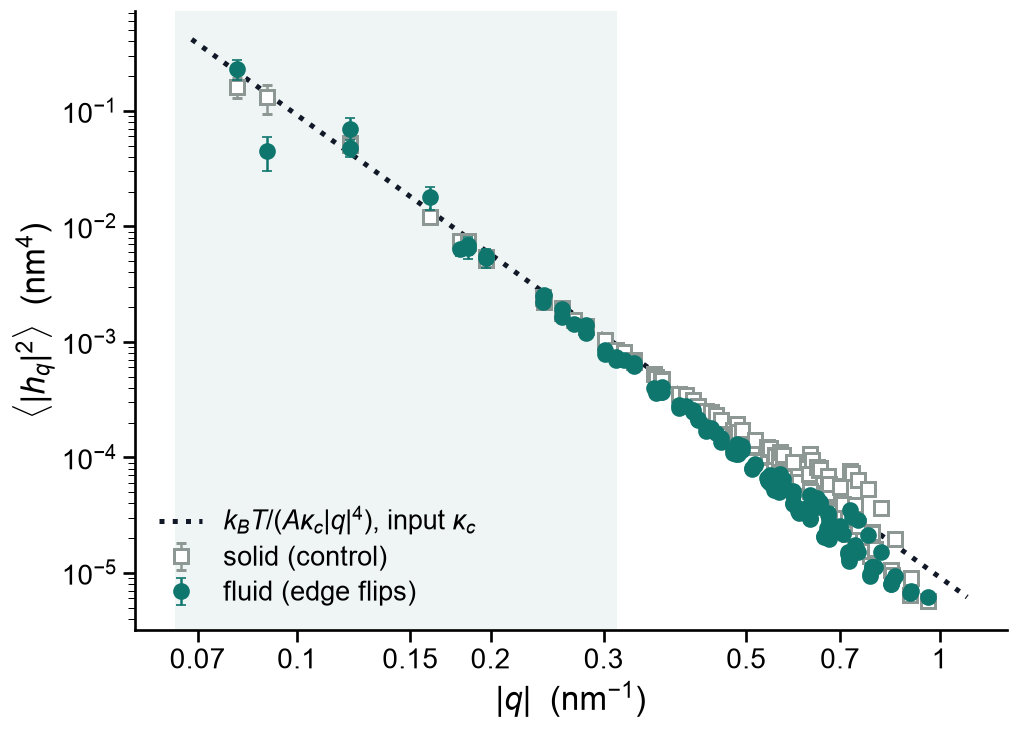

In [9]:
qq = np.logspace(np.log10(rc["q"].min() * 0.85), np.log10(rc["q"].max() * 1.15), 200)
fig, ax = plt.subplots(figsize=(8.8, 6.4))
ax.axvspan(rc["q"].min() * 0.8, QDX_MAX / lat.d_face_x, color=TEAL, alpha=0.07, lw=0, zorder=0)
ax.plot(qq, KBT / (lat.area * KC_IN * qq ** 4), ":", color=INK, lw=3.0, zorder=2,
        label=r"$k_BT/(A\kappa_c|q|^4)$, input $\kappa_c$")
ax.errorbar(rc["q"], rc["S"], yerr=rc["E"], fmt="s", ms=8, mfc="white", mec=GREY, ecolor=GREY,
            elinewidth=1.5, mew=1.8, lw=0, zorder=3, label="solid (control)")
ax.errorbar(rf["q"], rf["S"], yerr=rf["E"], fmt="o", ms=9, mfc=TEAL, mec=TEAL, ecolor=TEAL,
            elinewidth=1.5, lw=0, zorder=4, label="fluid (edge flips)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel(r"$|q|$  (nm$^{-1}$)"); ax.set_ylabel(r"$\langle |h_q|^2 \rangle$  (nm$^4$)")
nice_logx(ax)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()

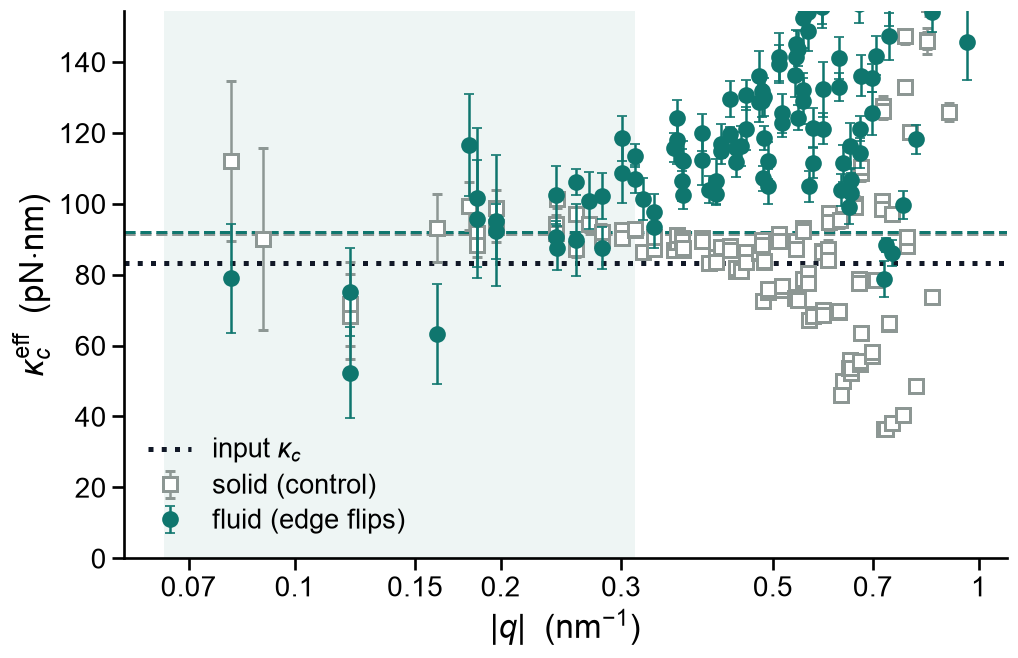

dashed lines: the fitted kc of each run


In [10]:
fig, ax = plt.subplots(figsize=(8.8, 5.8))
ax.axvspan(rc["q"].min() * 0.8, QDX_MAX / lat.d_face_x, color=TEAL, alpha=0.07, lw=0, zorder=0)
ax.axhline(KC_IN, color=INK, lw=3.0, ls=":", zorder=2, label=r"input $\kappa_c$")
ax.errorbar(rc["q"], rc["kc_eff"], yerr=rc["kc_err"], fmt="s", ms=8, mfc="white", mec=GREY, ecolor=GREY,
            elinewidth=1.5, mew=1.8, lw=0, zorder=3, label="solid (control)")
ax.errorbar(rf["q"], rf["kc_eff"], yerr=rf["kc_err"], fmt="o", ms=9, mfc=TEAL, mec=TEAL, ecolor=TEAL,
            elinewidth=1.5, lw=0, zorder=4, label="fluid (edge flips)")
ax.axhline(rc["kc"], color=GREY, lw=1.8, ls="--", zorder=1)
ax.axhline(rf["kc"], color=TEAL, lw=1.8, ls="--", zorder=1)
ax.set_xscale("log")
ax.set_xlabel(r"$|q|$  (nm$^{-1}$)"); ax.set_ylabel(r"$\kappa_c^{\mathrm{eff}}$  (pN$\cdot$nm)")
ax.set_ylim(0, KC_IN * 1.85)
nice_logx(ax)
ax.legend(loc="lower left")
plt.tight_layout()
plt.show()
print("dashed lines: the fitted kc of each run")

The number to carry is the ratio of the two $\kappa_c$ at equal treatment —
both through the subdivision route, so whatever the reader does it does to
both — rather than either value against the input. The solid run itself reads
about 10% above the input $\kappa_c$; that is how the discrete bending energy
relates to the continuum one on this mesh, and it is the same energy in both
runs. Past the fitting window both spectra roll off, which is the mesh no
longer resolving the surface; what to look for there is whether the fluid one
rolls off *earlier*, which would say an irregular patch is a coarser one.

In [11]:
(kc_c, sg_c), (kc_ce, sg_ce) = blockwise(h_ctrl_sub)
(kc_f, sg_f), (kc_fe, sg_fe) = blockwise(h_fluid)
ratio = kc_f / kc_c
ratio_err = ratio * np.sqrt((kc_ce / kc_c) ** 2 + (kc_fe / kc_f) ** 2)
w = rc["win"]
tail = (rc["q"] * lat.d_face_x > QDX_MAX)
rolloff = np.median((rf["S"] / rc["S"])[tail])

print(f"kappa_c, solid control : {kc_c:6.2f} +- {kc_ce:4.2f} pN.nm  ({kc_c / KBT:5.2f} kT)   slope {rc['slope']:+.3f}")
print(f"kappa_c, fluid         : {kc_f:6.2f} +- {kc_fe:4.2f} pN.nm  ({kc_f / KBT:5.2f} kT)   slope {rf['slope']:+.3f}")
print(f"ratio fluid / solid    : {ratio:.3f} +- {ratio_err:.3f}   ({abs(ratio - 1) / ratio_err:.1f} standard errors from 1)")
print(f"input kappa_c          : {KC_IN:6.2f} pN.nm; solid reads {kc_c / KC_IN - 1:+.1%}, fluid {kc_f / KC_IN - 1:+.1%} of it")
print(f"beyond the window      : fluid / solid power = {rolloff:.3f} (median over {tail.sum()} modes)")
print()
if abs(ratio - 1) <= 2 * ratio_err:
    print(f"VERDICT: the fluid membrane returns the same bending modulus as the solid one, "
          f"to {ratio_err:.1%} ({abs(ratio - 1):.1%} apart).")
else:
    print(f"VERDICT: the fluid membrane's bending modulus differs from the solid one by "
          f"{ratio - 1:+.1%}, {abs(ratio - 1) / ratio_err:.1f} standard errors -- not the same.")

kappa_c, solid control :  86.70 +- 3.38 pN.nm  (20.79 kT)   slope -3.968
kappa_c, fluid         :  86.39 +- 5.00 pN.nm  (20.72 kT)   slope -4.326
ratio fluid / solid    : 0.996 +- 0.070   (0.1 standard errors from 1)
input kappa_c          :  83.40 pN.nm; solid reads +4.0%, fluid +3.6% of it
beyond the window      : fluid / solid power = 0.603 (median over 105 modes)

VERDICT: the fluid membrane returns the same bending modulus as the solid one, to 7.0% (0.4% apart).


---
## 4. Tension

The second half of the gate. A tether that is zero inside its range should put
no tension into the membrane; the harmonic spring it replaced would have. The
fit above returns $\sigma$ alongside $\kappa_c$; here it is refitted block by
block so that it comes with an error bar, for both runs.

In [12]:
for tag, h in (("solid (control)", h_ctrl_sub), ("fluid (edge flips)", h_fluid)):
    (kc_m, sg_m), (kc_e, sg_e) = blockwise(h)
    print(f"{tag:20s} kc = {kc_m:6.2f} +- {kc_e:4.2f} pN.nm    sigma = {sg_m:+6.3f} +- {sg_e:5.3f} pN/nm"
          f"    (|sigma| / kc q_min^2 = {abs(sg_m) / (kc_m * rc['q'].min() ** 2):.3f})")
print("\nsigma is a tension only if it matters against kc q^2 at the lowest |q| the box holds;")
print("the last column is that ratio, and a tension too small to bend the spectrum reads as noise about zero.")

solid (control)      kc =  86.70 +- 3.38 pN.nm    sigma = +0.327 +- 0.200 pN/nm    (|sigma| / kc q_min^2 = 0.580)
fluid (edge flips)   kc =  86.39 +- 5.00 pN.nm    sigma = +1.046 +- 0.272 pN/nm    (|sigma| / kc q_min^2 = 1.864)

sigma is a tension only if it matters against kc q^2 at the lowest |q| the box holds;
the last column is that ratio, and a tension too small to bend the spectrum reads as noise about zero.


---
## 5. Is the fluid run long enough?

Half the length of the control, at half the time step: a quarter of the
physical time. The lowest-$|q|$ mode relaxes as $|q|^{-4}$ and converges last;
refitting from growing prefixes of the trajectory shows whether $\kappa_c$ has
settled, exactly as the solid notebook does for its own run.

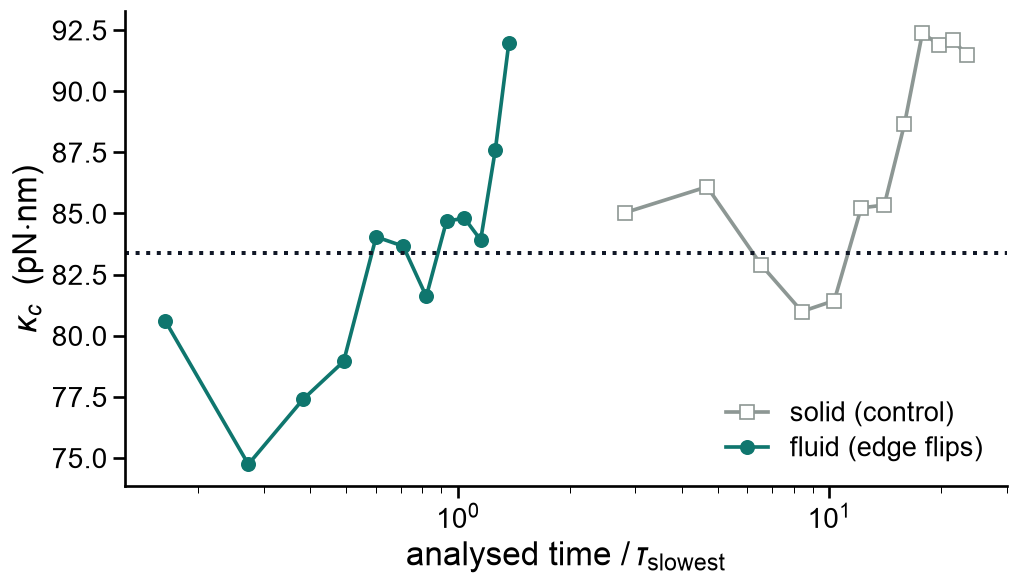

solid (control)      analysed 1280 us = 23.4 tau_slowest; kc over the last three prefixes [91.9, 92.09, 91.47]
fluid (edge flips)   analysed 75 us = 1.4 tau_slowest; kc over the last three prefixes [83.91, 87.61, 91.97]


In [13]:
tau_slow = KBT / (DIFF * A_CELL * KC_IN * rc["q"].min() ** 4)
fracs = np.linspace(0.12, 1.0, 12)
curves = {}
for tag, h, dtf in (("solid (control)", h_ctrl_sub, 2 * DT_FRAME_C), ("fluid (edge flips)", h_fluid, DT_FRAME_F)):
    rows = []
    for f in fracs:
        n = int(len(h) * f)
        S2d, _ = block_power(np.fft.fft2(h[:n], axes=(-2, -1)), lat, nblock=4)
        qv, Sv = q2d[keep], S2d[keep]
        win = qv * lat.d_face_x <= QDX_MAX
        kc_f, _ = ms.fit_kc_sigma(qv[win], Sv[win], lat.area, KBT)
        rows.append((n * dtf, kc_f))
    curves[tag] = np.array(rows)

fig, ax = plt.subplots(figsize=(8.8, 5.2))
for (tag, rows), colour, mk in zip(curves.items(), (GREY, TEAL), ("s", "o")):
    ax.plot(rows[:, 0] / tau_slow, rows[:, 1], mk + "-", color=colour, ms=8, lw=2.2, label=tag,
            mfc="white" if mk == "s" else colour)
ax.axhline(KC_IN, color=INK, lw=2.4, ls=":")
ax.set_xscale("log")
ax.set_xlabel(r"analysed time $/\,\tau_{\mathrm{slowest}}$"); ax.set_ylabel(r"$\kappa_c$  (pN$\cdot$nm)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()
for tag, rows in curves.items():
    print(f"{tag:20s} analysed {rows[-1, 0]:.0f} us = {rows[-1, 0] / tau_slow:.1f} tau_slowest; "
          f"kc over the last three prefixes {rows[-3:, 1].round(2).tolist()}")

---
## 6. Two things the reader could get wrong

**The interpolation level.** Off the vertices the subdivision route is linear
interpolation on a net of edge $l/2^k$, and a moving mesh puts every grid point
off the vertices. Level 3 is eight times the cost of level 2; on a subset of
the fluid frames both are run and the fitted $\kappa_c$ compared.

**Folds.** The Monge gauge presumes the surface is a graph over the plane. A
fluid control net is not, quite: with the vertices free to move in plane, a
few per cent of its triangles turn over in projection within the first
thousands of steps. The limit net inherits almost none of that, but a single
inverted facet breaks a point locator built on the mesh's own connectivity,
which is why the reader triangulates the projected limit points afresh
(Delaunay) — identical to the mesh wherever it is well shaped, and a
regularisation across the rare fold. The counts are reported here so the
"rare" is a number.

**The seam.** Periodicity is realised by duplicated rings, and a flip is
refused wherever it would touch one, so the duplicate rings keep the lattice
connectivity while their partners across the box may have flipped. The limit
surface is therefore not exactly periodic near the seam. That is a property of
the simulation, not of the reader, and `seam_mismatch` measures it: the r.m.s.
difference between $h$ just inside one edge of the tile and at the same points
shifted by the box, against the r.m.s. of $h$ itself.

In [14]:
folds = []
for f in range(BURN_F, fluid.coords.shape[0], max(1, (fluid.coords.shape[0] - BURN_F) // 40)):
    s_ = mfs.SubdividedSurface(mfs.connectivity_for_frame(fluid.face_frames, int(fluid.frame_iterations[f])),
                               fluid.coords.shape[1], LEVELS)
    folds.append(s_.fold_counts(fluid.coords[f]))
ci = np.array([d["control_inverted"] for d in folds]); fi = np.array([d["fine_inverted"] for d in folds])
print(f"folds over {len(folds)} fluid frames: control net {ci.mean():.1f} of {folds[0]['control_faces']} triangles inverted "
      f"on average (max {ci.max()}, {ci.mean() / folds[0]['control_faces']:.2%}); "
      f"level-{LEVELS} limit net {fi.mean():.2f} of {folds[0]['fine_faces']} (max {fi.max()}), "
      f"{(fi > 0).mean():.0%} of frames with any")

sub = np.arange(BURN_F, fluid.coords.shape[0], max(1, (fluid.coords.shape[0] - BURN_F) // 150))
t0 = time.perf_counter()
h2 = mfs.monge_heights(fluid.coords[sub], fluid.frame_iterations[sub], fluid.face_frames, X, Y, 2)
h3 = mfs.monge_heights(fluid.coords[sub], fluid.frame_iterations[sub], fluid.face_frames, X, Y, 3)
r2, r3 = fit_spectrum(h2), fit_spectrum(h3)
print(f"{len(sub)} fluid frames at levels 2 and 3 ({time.perf_counter() - t0:.0f} s): "
      f"kc {r2['kc']:.2f} vs {r3['kc']:.2f} pN.nm, slope {r2['slope']:+.3f} vs {r3['slope']:+.3f}; "
      f"max |h2 - h3| = {np.abs(h2 - h3).max():.2e} nm, rms {np.sqrt(np.mean((h2 - h3) ** 2)):.2e} nm")

for tag, run_, lat_, h_ in (("solid (control)", ctrl, lat, h_ctrl_sub), ("fluid (edge flips)", fluid, lat_f, h_fluid)):
    m = mfs.seam_mismatch(run_.coords, run_.frame_iterations, run_.face_frames, lat_,
                          surf._ox, surf._oy, levels=LEVELS, stride=max(1, run_.coords.shape[0] // 60))
    rms_field = float(np.sqrt(np.mean((h_ - h_.mean(axis=(1, 2), keepdims=True)) ** 2)))
    print(f"{tag:20s} seam mismatch {m['rms_mismatch']:.2e} nm against the field's r.m.s. h {rms_field:.3f} nm "
          f"({m['rms_mismatch'] / rms_field:.2%}), over {m['frames']} frames")

folds over 42 fluid frames: control net 59.9 of 960 triangles inverted on average (max 80, 6.24%); level-2 limit net 90.86 of 15360 (max 226), 90% of frames with any


188 fluid frames at levels 2 and 3 (58 s): kc 92.57 vs 91.37 pN.nm, slope -4.284 vs -4.269; max |h2 - h3| = 3.78e-02 nm, rms 4.18e-03 nm


solid (control)      seam mismatch 2.14e-08 nm against the field's r.m.s. h 0.974 nm (0.00%), over 61 frames


fluid (edge flips)   seam mismatch 1.08e-03 nm against the field's r.m.s. h 0.968 nm (0.11%), over 63 frames


---
## 7. Limits

**The divergence, and the ghost band.** The first fluid runs of this
notebook diverged — after 8 700 steps at $\Delta t = 0.002$ and after 94 000
at 0.001 — with the *reported* tether energy climbing the whole way. The
membrane was not the problem: split by band, 93–98% of that energy was in the
ghost rings, whose lattice edges join positions copied from an interior that
had mixed, and stretch to 17 nm as neighbour survival decays. The interior's
tether energy, and the bending energy the spectrum measures, were flat
throughout. The force those stale edges put on the duplicate ring was mapped
into the interior by $M^{-T}$ before the duplicates were overwritten, and that
is what folded a face at the seam. `Mesh::edge_carries_tether()` now excludes
edges with two copied endpoints from the tether; `docs/fluidity_results.md`
section 8 has the probes and the split. The run analysed here, if section 0
reports a divergence, predates that fix and is trustworthy up to it: the
height field over its frames is stationary.

**Length.** A run that diverged at 94 000 steps is 94 µs, about 1.4 relaxation
times of the slowest mode in the box. Section 5's prefix fits show how far
$\kappa_c$ has settled; the lowest modes are where a longer run pays.

**Seam.** Section 6's number is the price of realising periodicity with
duplicated rings under a move that cannot be mirrored across them. Mirroring
flips onto the periodic images would remove it and is not implemented.

**Reader.** Linear interpolation at level 2 is a low-pass filter with an
attenuation of order $(|q|\,l/4)^2/8$ — under 1% inside the fitting window on
the lattice, and section 6 measures it directly on the moving mesh. The
resampler's exact inversion for irregular patches would need Stam's
eigenbasis evaluation and is not implemented; nothing here depends on it.

**Statistics.** A quarter of the control's physical time. Section 5 is the
check; the error bars in section 3 are honest about the rest.